In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_selection import SelectKBest, chi2
import json
import time


In [8]:
df = pkl.load(open('project8.pkl', 'rb'))
df.shape

(2027, 19)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               2027 non-null   int64  
 1   post_id                  2027 non-null   object 
 2   self_text                2027 non-null   object 
 3   user_is_verified         2027 non-null   object 
 4   controversiality         2027 non-null   float64
 5   ups                      2027 non-null   float64
 6   downs                    2027 non-null   int64  
 7   subreddit                2027 non-null   object 
 8   score                    2027 non-null   float64
 9   user_awardee_karma       2022 non-null   float64
 10  user_awarder_karma       2022 non-null   float64
 11  user_total_karma         2022 non-null   float64
 12  user_comment_karma       2022 non-null   float64
 13  user_link_karma          2022 non-null   float64
 14  post_score              

### Preprocessing

In [10]:
df["preprocessed_text"] = df["self_text"].apply(lambda x: x.lower())

In [11]:
stop_words = set(stopwords.words('english'))
df["tokenized_text"] = df["preprocessed_text"].apply(lambda x: word_tokenize(x))
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word not in stop_words])
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word.isalnum()])
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if len(word) > 1]) # remove single character words, this can help with removing punctuation. 


In [12]:
#group by subreddit
grouped = df.groupby('subreddit')
df_cli_sci = grouped.get_group('climate_science')
df_cli_skp = grouped.get_group('climateskeptics')

print(df_cli_sci.shape)
print(df_cli_skp.shape)

(442, 21)
(1585, 21)


In [13]:
cli_sci_words = [word for words in df_cli_sci["tokenized_text"].values for word in words]
cli_skp_words = [word for words in df_cli_skp["tokenized_text"].values for word in words]

In [14]:
print(len(cli_sci_words))
print(len(cli_skp_words))

123994
487206


In [15]:
common_words = set()
with open ("common_words.txt", "r") as f:
    for line in f:
        common_words.add(line.strip())
        
print(len(common_words))

cli_sci_words = [word for word in cli_sci_words if word not in common_words]
cli_skp_words = [word for word in cli_skp_words if word not in common_words]

print(len(cli_sci_words))
print(len(cli_skp_words))


63
99671
393779


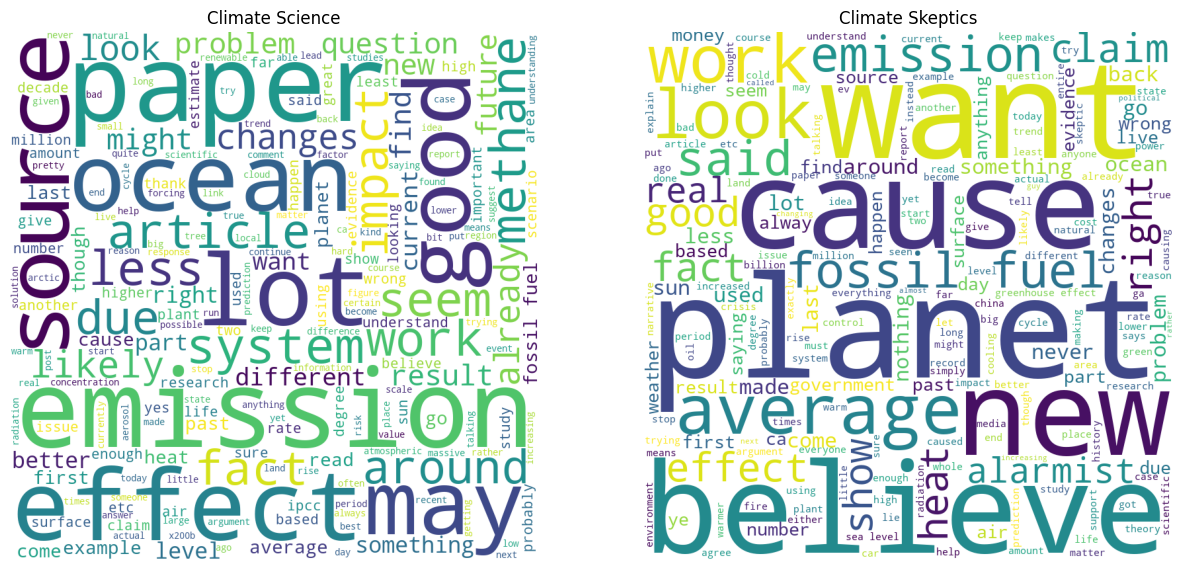

In [16]:
#word cloud for climate science and climate skeptics in subplots
fig, ax = plt.subplots(1, 2, figsize=(15, 15))

wordcloud_cli_sci = WordCloud(width=800, height=800, background_color='white').generate(' '.join(cli_sci_words))
ax[0].imshow(wordcloud_cli_sci)
ax[0].axis('off')
ax[0].set_title('Climate Science')

wordcloud_cli_skp = WordCloud(width=800, height=800, background_color='white').generate(' '.join(cli_skp_words))
ax[1].imshow(wordcloud_cli_skp)
ax[1].axis('off')
ax[1].set_title('Climate Skeptics')

plt.show()

In [17]:
from collections import Counter

total_cli_sci_words = len(cli_sci_words)
total_cli_skp_words = len(cli_skp_words)

cli_sci_word_freq = Counter({word: count / total_cli_sci_words for word, count in Counter(cli_sci_words).items()})
cli_skp_word_freq = Counter({word: count / total_cli_skp_words for word, count in Counter(cli_skp_words).items()})

print(cli_sci_word_freq.most_common(20))
print(cli_skp_word_freq.most_common(20))


[('emissions', 0.004013203439315348), ('methane', 0.0032807938116402964), ('good', 0.0028995394849053386), ('paper', 0.002367790029196055), ('lot', 0.002357757020597767), ('ocean', 0.00227749295181146), ('heat', 0.0022674599432131715), ('may', 0.0022574269346148828), ('effect', 0.0021871958744268645), ('less', 0.0021771628658285762), ('likely', 0.002116964814238846), ('ipcc', 0.0020968987970422692), ('since', 0.002066799771247404), ('might', 0.0020166347282559623), ('greenhouse', 0.001996568711059385), ('due', 0.0019765026938628086), ('already', 0.0019464036680679436), ('around', 0.0019464036680679436), ('different', 0.0019464036680679436), ('changes', 0.0019263376508713668)]
[('heat', 0.0031185004786949025), ('planet', 0.002897564369862283), ('effect', 0.0028163005137399402), ('gas', 0.002595364404907321), ('greenhouse', 0.0024074417376244036), ('since', 0.002211900583830016), ('oil', 0.0022042820973185466), ('weather', 0.002196663610807077), ('believe', 0.002171268655768845), ('new',

In [ ]:
#after we have made a list of common words, we can remove them from the tokenized text
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word not in common_words])

In [29]:
top_5000_words = set()
with open("top_5000_words.txt", "r") as f:
    for line in f:
        top_5000_words.add(line.strip())
        
df["preprocessed_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word in top_5000_words])

df["preprocessed_text"].head()

0    [yes, modeling, anything, less, resolution, ea...
1    [official, paper, describes, effect, supposed,...
2    [read, article, month, ago, sure, claims, look...
3         [paul, provides, textbook, taught, students]
4    [good, interview, hits, lot, climategate, some...
Name: preprocessed_text, dtype: object

### Task 1

In [54]:
#download the google news word2vec model
import gensim.downloader as api
word2vec_model = api.load('word2vec-google-news-300')

In [ ]:
most_prominent_words = ['emission', 'source', 'planet', 'believe']
cosine_similarities = cosine_similarity(word2vec_model[most_prominent_words])

cos_sim_df = pd.DataFrame(cosine_similarities, columns=most_prominent_words, index=most_prominent_words)
cos_sim_df

,emission,source,planet,believe
emission,1.000000,0.050124,0.215118,0.022043
source,0.050124,1.000001,0.107579,0.044794
planet,0.215118,0.107579,1.000000,0.084979
believe,0.022043,0.044794,0.084979,1.000000


### Task 2

In [ ]:
#averaging the word vectors into a single vector for each post 
df["avg_sentence_vector"] = df["preprocessed_text"].apply(lambda x: np.mean([word2vec_model[word] for word in x if word in word2vec_model.key_to_index], axis=0))

#check the dimension of the average sentence vector of each post
df["avg_sentence_vector"].apply(lambda x: x.shape).value_counts()
    

AttributeError: 'LogisticRegression' object has no attribute 'key_to_index'

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

X = np.array(df["avg_sentence_vector"].values.tolist())
y = df["subreddit"].apply(lambda x: 1 if x == "climate_science" else 0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

C:\Users\randy\AppData\Local\Temp\ipykernel_28992\13024906.py:8: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.array(df["avg_sentence_vector"].values.tolist())


In [49]:
def train_and_test(model, X_train, X_test, y_train, y_test):
    time_start = time.time()
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    time_elapsed = (time.time() - time_start) / 60
    
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'time_elapsed(m)': time_elapsed}

In [50]:
classifiers = [
    ("Logistic Regression", LogisticRegression()), 
    ("Random Forest", RandomForestClassifier()), 
    ("Naive Bayes", MultinomialNB()), 
    ("SVM", SVC())
]
results = {}

for classifier in classifiers:
    name, model = classifier
    results[name] = train_and_test(model, X_train, X_test, y_train, y_test)
    
print(json.dumps(results, indent=4))

NameError: name 'X_train' is not defined